<a href="https://colab.research.google.com/github/kmukhiddinov/purchase-prediction/blob/main/purchase_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ML Project**

In [21]:
import pandas as pd

In [22]:
df = pd.read_csv("online_shoppers_intention.csv")

---

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           




###18 columns, 12330 rows, no nulls. 2 object columns (Month, VisitorType), 2 bool (Weekend, Revenue) need encoding before modeling.







---

In [24]:
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908




> Classes imbalanced: [True 1908 vs False 10422]. Accuracy alone won't be reliable metric here.




---

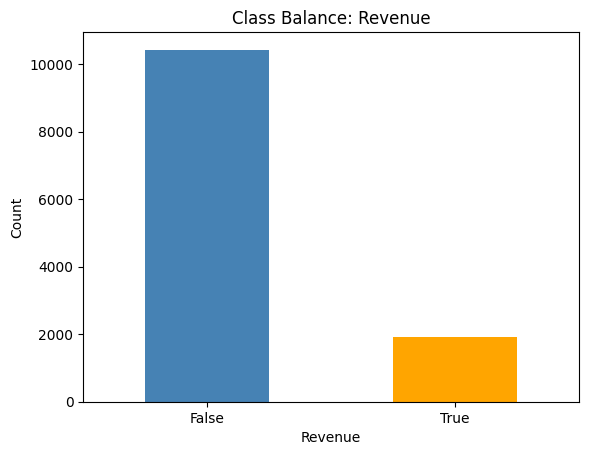

In [25]:
import matplotlib.pyplot as plt

df['Revenue'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Class Balance: Revenue')
plt.xlabel('Revenue')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()



> Revenue Class Distribution



---

In [26]:
df = pd.get_dummies(df, columns = ['Month', 'VisitorType'])

In [27]:
pd.set_option('display.max_columns', None)

In [28]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)



> Encoded Month and VisitorType to numeric columns using get_dummies(). Converted all booleans to int (0/1). Dataset now has 29 columns.



---


In [29]:
df.duplicated().sum()

np.int64(125)

In [30]:
df = df.drop_duplicates()
print(df.shape)

(12205, 29)





> Found and removed 125 duplicate rows. Final dataset: 12,205 rows, all numeric.



---

In [31]:
X = df.drop(columns=['Revenue'])
y = df['Revenue']

print(X.shape)
print(y.shape)

(12205, 28)
(12205,)




> Separate X (features) and y (target)



---


In [32]:
from sklearn.model_selection import train_test_split


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (9764, 28)
X_test shape: (2441, 28)
y_train shape: (9764,)
y_test shape: (2441,)




> Import train_test_split from sklearn and split the data (80% / 20%).



---


In [34]:
print("y_train distribution:")
print(y_train.value_counts())
print("\ny_test distribution:")
print(y_test.value_counts())

y_train distribution:
Revenue
0    8218
1    1546
Name: count, dtype: int64

y_test distribution:
Revenue
0    2079
1     362
Name: count, dtype: int64




>Class balance preserved (~84/16).



---

In [35]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=10000,
    solver='saga',
    class_weight='balanced',
    random_state=42
)
model_lr.fit(X_train, y_train)
predictions_lr = model_lr.predict(X_test)

print("Logistic Regression trained and predictions made on test set.")

Logistic Regression trained and predictions made on test set.




> Trained Logistic Regression on X_train with class_weight='balanced' to account for class imbalance. Made predictions on X_test.



---

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(y_test, predictions_lr)
precision = precision_score(y_test, predictions_lr)
recall = recall_score(y_test, predictions_lr)
cm = confusion_matrix(y_test, predictions_lr)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Confusion Matrix:\n{cm}")

Accuracy: 0.8304
Precision: 0.4592
Recall: 0.8094
Confusion Matrix:
[[1734  345]
 [  69  293]]




> Evaluated Logistic Regression: Accuracy 83%, Precision 46%, Recall 81%. Class_weight='balanced' helped the model catch most buyers (high recall),at the cost of more false positives (lower precision).



---

In [37]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_rf.fit(X_train, y_train)
predictions_rf = model_rf.predict(X_test)

print("Random Forest trained and predictions made on test set.")

Random Forest trained and predictions made on test set.




> Trained Random Forest (100 trees) with class_weight='balanced' for comparison with Logistic Regression. Made predictions on X_test.



---

In [38]:
predictions_rf_metrics_accuracy = accuracy_score(y_test, predictions_rf)
predictions_rf_metrics_precision = precision_score(y_test, predictions_rf)
predictions_rf_metrics_recall = recall_score(y_test, predictions_rf)
cm_rf = confusion_matrix(y_test, predictions_rf)

print(f"Accuracy: {predictions_rf_metrics_accuracy:.4f}")
print(f"Precision: {predictions_rf_metrics_precision:.4f}")
print(f"Recall: {predictions_rf_metrics_recall:.4f}")
print(f"Confusion Matrix:\n{cm_rf}")

Accuracy: 0.9045
Precision: 0.7549
Recall: 0.5276
Confusion Matrix:
[[2017   62]
 [ 171  191]]




> Random Forest: Accuracy 90%, Precision 75%, Recall 53%. Higher overall accuracy and precision than Logistic Regression,  but lower recall — misses more actual buyers. Trade-off depends on business goal: LogReg for catching more buyers, RF for more confident predictions.

---

In [39]:
import pandas as pd

importances = model_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))

                    feature  importance
8                PageValues    0.375697
7                 ExitRates    0.097540
5   ProductRelated_Duration    0.088647
4            ProductRelated    0.069681
6               BounceRates    0.056067
1   Administrative_Duration    0.047643
0            Administrative    0.037562
22                Month_Nov    0.030632
13              TrafficType    0.028335
12                   Region    0.026764




> Feature importance: PageValues is the strongest predictor (37.6%),
followed by ExitRates (9.8%), ProductRelated_Duration (8.9%), ProductRelated (7%).





---

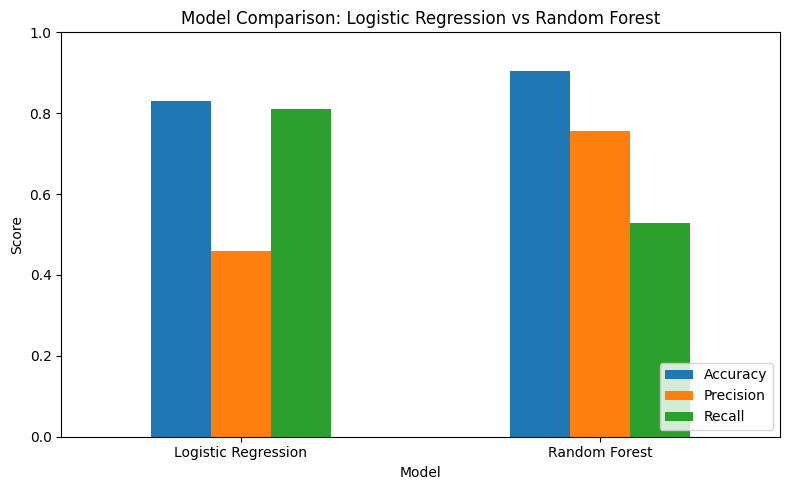

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

metrics_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.8304, 0.9045],
    'Precision': [0.4592, 0.7549],
    'Recall': [0.8094, 0.5276]
})

metrics_comparison.plot(x='Model', kind='bar', figsize=(8, 5))
plt.title('Model Comparison: Logistic Regression vs Random Forest')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



> Visual comparison confirms the trade-off: Random Forest wins on accuracy/precision,
Logistic Regression wins on recall.



---

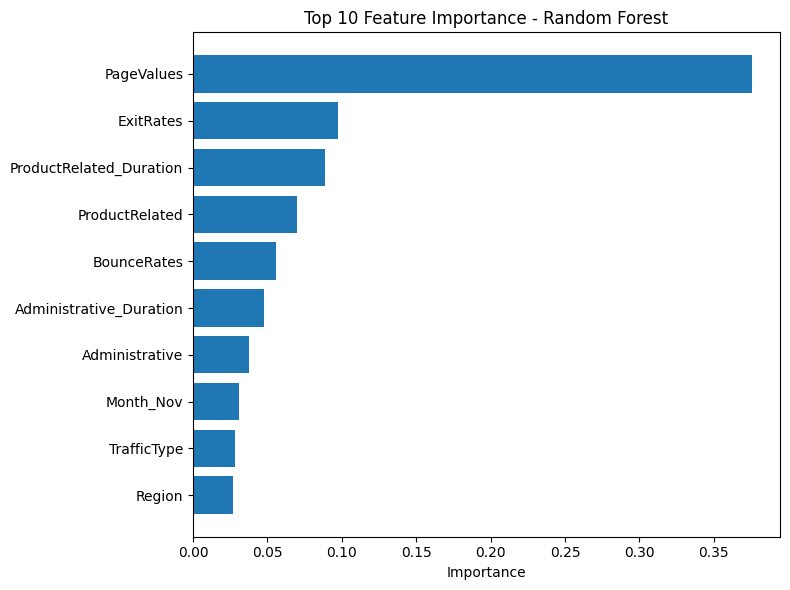

In [41]:
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df['feature'][:10], feature_importance_df['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



> PageValues clearly dominates feature importance, more than 3x the next feature. Product-browsing behavior (ExitRates,ProductRelated_Duration, ProductRelated) matters more than demographic/technical features (Region, TrafficType, Month).

